# Parser 실험

텍스트/ 표/ 이미지 파서 실험

| 항목           | 수치             |
| ------------ | -------------- |
| 문서 수         | 100            |
| 총 페이지 수      | 7,576          |
| 표 포함 페이지 수   | 5,537 (73.09%) |
| 이미지 포함 페이지 수 | 276 (3.64%)    |
| 총 표 개수       | 12,142         |
| 총 이미지 개수     | 335            |


## 샘플 PDF
- **파일**: `고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf`
- **1**: PyPDFLoader → 텍스트 추출
- **2**: PyMuPDF(fitz) → 이미지 추출
- **3**: pdfplumber → 표 추출

### 텍스트 추출: PyPDFLoader

In [5]:
# 1: PyPDFLoader 기반 텍스트 파싱
from langchain_community.document_loaders import PyPDFLoader

PDF_PATH = "/Users/apple/Team2-RAG-Project/고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf"

loader = PyPDFLoader(PDF_PATH)
pages = loader.load()

print(f"총 페이지 수: {len(pages)}\n")

# 처음 3페이지 내용 샘플 출력
for i, page in enumerate(pages[:3]):
    print(f"=== 페이지 {page.metadata['page'] + 1} ===")
    print(page.page_content[:500])  # 각 페이지 앞 500자
    print()

총 페이지 수: 297

=== 페이지 1 ===
                                                                                          
   
 
-1- 
 
 
 
제  안  요  청  서 
 
 
고려대학교   
차세대  포털 ·학사  정보시스템  구축  사업  
 
 
 
 
 
 
 
 
2024. 7. 01 
 
 
 
 
 
 
 
 
※  본  자료는  제안내용의  설명을  위한  배포자료로,  이외 목적으로  무단복제,  전달  및 사용하는  행위를  금함. 
 
 

=== 페이지 2 ===
                                                                                          
   
 
-2- 
 
 
 
 
 
목   차    
. Ⅰ 사업개요  ··················································································································  4 
1.  사업 개요  ··············································································································  4 
2.  사업 배경  ··············································································································  

=== 페이지 3 ===
                                                                                          
   
 
-3- 
 
 
 
 
 
2.   제안서 작성 유의사항  ························

### 2. 이미지 추출: PyMuPDF(fitz)

[페이지 1] 저장: page1_img1.jpeg  (901x496px, 50,442 bytes)
[페이지 1] 저장: page1_img2.png  (416x117px, 9,089 bytes)
[페이지 1] 저장: page1_img3.jpeg  (878x512px, 80,191 bytes)
[페이지 1] 저장: page1_img4.png  (1035x552px, 16,407 bytes)
[페이지 1] SKIP (로고 추정 141x40px)
[페이지 1] 저장: page1_img6.jpeg  (538x255px, 37,180 bytes)
[페이지 1] SKIP (로고 추정 2x2px)
[페이지 1] 저장: page1_img8.jpeg  (1115x710px, 165,432 bytes)
[페이지 1] 저장: page1_img9.jpeg  (538x255px, 31,452 bytes)
[페이지 1] 저장: page1_img10.jpeg  (538x255px, 44,148 bytes)
[페이지 1] 저장: page1_img11.jpeg  (538x255px, 40,408 bytes)
[페이지 1] 저장: page1_img12.jpeg  (538x255px, 47,877 bytes)
[페이지 1] 저장: page1_img13.jpeg  (538x255px, 28,000 bytes)
[페이지 1] 저장: page1_img14.jpeg  (538x297px, 35,054 bytes)
[페이지 1] 저장: page1_img15.jpeg  (538x267px, 40,637 bytes)
[페이지 1] 저장: page1_img16.jpeg  (538x297px, 51,295 bytes)
[페이지 1] 저장: page1_img17.jpeg  (538x297px, 47,327 bytes)
[페이지 1] 저장: page1_img18.jpeg  (538x297px, 32,069 bytes)
[페이지 1] 저장: page1_img19.jpeg  (538x297px, 47,012 bytes

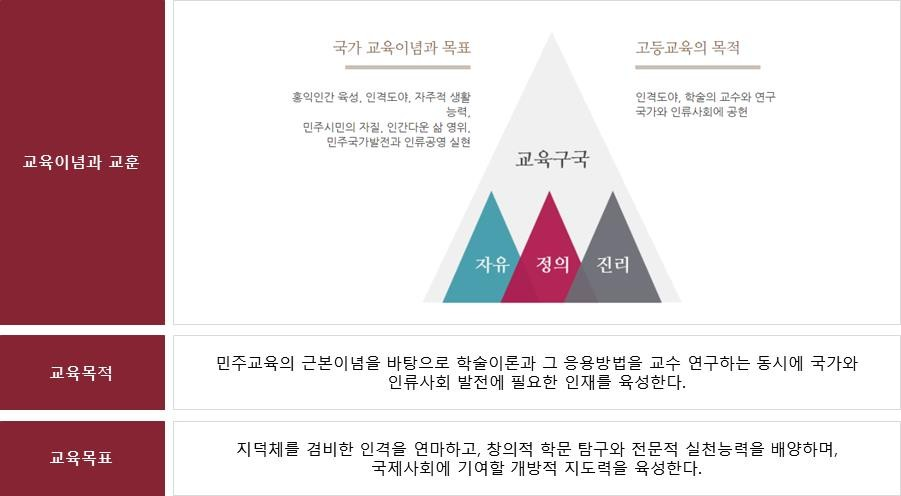


--- page100_img10.jpeg ---


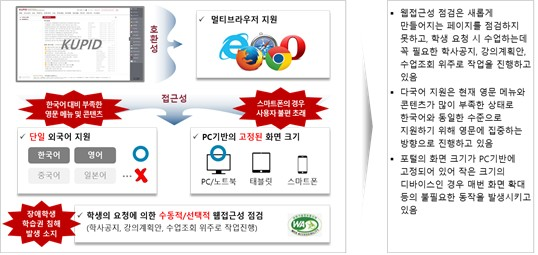


--- page100_img11.jpeg ---


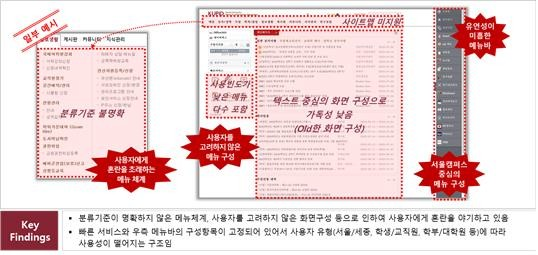

In [4]:
# 2: PyMuPDF(fitz) 기반 이미지 파싱
import fitz  # PyMuPDF
import os
from IPython.display import display, Image

PDF_PATH = "/Users/apple/Team2-RAG-Project/고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf"
OUTPUT_DIR = "/Users/apple/Team2-RAG-Project/data/parsed/image/sample"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 로고 제외 기준: 너비 또는 높이가 100px 이하인 이미지는 스킵
MIN_SIZE = 100

doc = fitz.open(PDF_PATH)
image_count = 0
skip_count = 0

for page_num in range(len(doc)):
    page = doc[page_num]
    images = page.get_images(full=True)  # 페이지 내 이미지 목록

    for img_index, img_info in enumerate(images):
        xref = img_info[0]
        width, height = img_info[2], img_info[3]  # 원본 이미지 크기

        # 크기 기반 필터링: 작은 이미지(로고 등) 제외
        if width <= MIN_SIZE or height <= MIN_SIZE:
            skip_count += 1
            print(f"[페이지 {page_num+1}] SKIP (로고 추정 {width}x{height}px)")
            continue

        base_image = doc.extract_image(xref)
        image_bytes = base_image["image"]
        ext = base_image["ext"]

        filename = f"page{page_num+1}_img{img_index+1}.{ext}"
        filepath = os.path.join(OUTPUT_DIR, filename)

        with open(filepath, "wb") as f:
            f.write(image_bytes)

        image_count += 1
        print(f"[페이지 {page_num+1}] 저장: {filename}  ({width}x{height}px, {len(image_bytes):,} bytes)")

doc.close()
print(f"\n✅ 저장된 이미지: {image_count}개  |  스킵(로고 추정): {skip_count}개")
print(f"저장 경로: {OUTPUT_DIR}")

# 처음 3개 이미지 미리보기
saved = sorted(os.listdir(OUTPUT_DIR))[:3]
for fname in saved:
    print(f"\n--- {fname} ---")
    display(Image(filename=os.path.join(OUTPUT_DIR, fname), width=400))


### 2-2. 이미지에서 정보 추출

In [10]:
# OCR로 이미지에서 텍스트 추출
import pytesseract
from PIL import Image as PILImage
import os

# 처음 10개의 이미지만 슬라이싱하여 가져옵니다.
saved_images = sorted(os.listdir(OUTPUT_DIR))[:10]

print(f"총 {len(saved_images)}개의 이미지에 대해 OCR 추출을 시작합니다...\n")

for fname in saved_images:
    img_path = os.path.join(OUTPUT_DIR, fname)
    
    try:
        # PIL을 사용해 이미지 로드
        img = PILImage.open(img_path)
        
        # 한국어(kor)와 영어(eng) 동시 인식
        extracted_text = pytesseract.image_to_string(img, lang='kor+eng').strip()
        
        print(f"--- 📄 {fname} OCR 결과 ---")
        if extracted_text:
            # 텍스트가 너무 길 수 있으므로 처음 300자만 출력
            preview_text = extracted_text[:300] + ("\n... [생략]" if len(extracted_text) > 300 else "")
            print(preview_text)
        else:
            print("(추출된 텍스트가 없습니다 / 도표나 단순 그림일 수 있습니다)")
        print("-" * 40 + "\n")
        
    except Exception as e:
        print(f"{fname} OCR 처리 중 오류 발생: {e}")

총 10개의 이미지에 대해 OCR 추출을 시작합니다...

--- 📄 page100_img1.jpeg OCR 결과 ---
국가 교육이념과 목표

인격도야, 학술의 교수와 연구

홍익인간 육성. 인격도야, 자주적 생활
국가와 인류사회에 공현

능력,

인주국가받전과 인류공영 실현

민주교육의 근본이념을 바탕으로 학솔이론과 그 응용방법을 교수 연구하는 동시에 국가와

인류사회 발전에 필요:

rt

지덕체를 겸비한 MAS 연마하고, 창의적 학문 탐구와 전문적 실천능력을 배양하며,
국제사회에 기여할 개방적 지도력을 육성한다.
----------------------------------------

--- 📄 page100_img10.jpeg OCR 결과 ---
+ sues gue ae
2p |  "GO xe                            gore sone seein
들                                                         Bon we 24 시 oasied
~          기구                                            Suse even game,
seam 위주로 Nee gee
28
sii                  + 39 sige 현재 Be 미와
5                   
... [생략]
----------------------------------------

--- 📄 page100_img11.jpeg OCR 결과 ---
wae 049 we 으로
2982.40
7008.08760

+ ME Mules 우역 미뉴바의 F3BRO| 고정되어 있어서 사용자 RUAE/M, ea) ANS, 학루/대학원 의 wet

000 ㆍ ㄷㄷ 0507 ge on 사요자고카 Ge waFe 으로 인하여 사용자 BER O82 Ne
Findings [nee

ie 조인
----------------------------------------

--- 📄 page100_img


=== 🤖 page100_img1.jpeg 이미지 요약 분석 중 (gpt-5-mini) ===


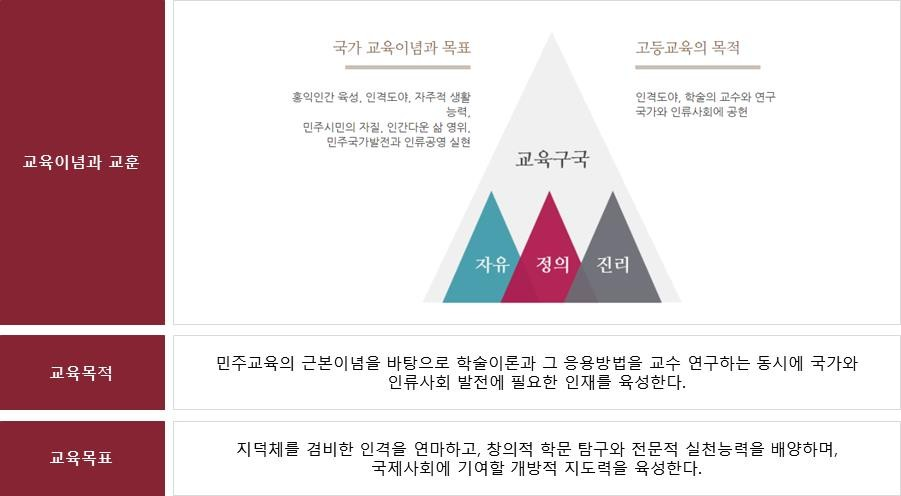


[LLM 요약 결과]
아래는 첨부된 이미지(‘고려대학교 차세대 포털 및 학사 정보시스템 구축사업’ 문서에서 추출)에 포함된 표·다이어그램·텍스트의 핵심 내용을 RAG(검색+생성) 데이터베이스에 저장하기 좋게 정리한 마크다운 요약입니다.

파일 출처(이미지 상 표시)
- 고려대학교 차세대 포털 및 학사 정보시스템 구축사업 (이미지 내 슬라이드 제목: 교육이념과 교훈)

요약(구조별)
1) 슬라이드 제목
- 교육이념과 교훈

2) 중앙 다이어그램 (삼각형)
- 최상단(삼각형 꼭대기): 교육구국
- 하부 3개 가치(삼각형 내부, 좌→중→우):
  - 자유
  - 정의
  - 진리

3) 다이어그램 좌측 상단(국가 교육이념과 목표)
- 주요 문장(이미지에서 읽힌 핵심어):
  - 홍익인간 육성, 인격도야, 자주적 생활능력
  - 민주시민의 자질; 인간다운 삶 영위, 민주국가발전과 인류공영 실현

4) 다이어그램 우측 상단(고등교육의 목적)
- 주요 문장(이미지에서 읽힌 핵심어):
  - 인격도야, 학술의 교수와 연구
  - 국가와 인류사회에 공헌

5) 하단 표: 교육목적 및 교육목표
- 교육목적 (원문)
  - 민주교육의 근본이념을 바탕으로 학술이론과 그 응용방법을 교수 연구하는 동시에 국가와 인류사회 발전에 필요한 인재를 육성한다.
- 교육목표 (원문)
  - 지덕체를 겸비한 인격을 연마하고, 창의적 학문 탐구와 전문적 실천능력을 배양하며, 국제사회에 기여할 개방적 지도력을 육성한다.

RAG 저장용 메타데이터(권장 필드)
- id: 고려대_교육이념_교훈_슬라이드_1
- title: 교육이념과 교훈 — 교육구국(자유·정의·진리), 교육목적·목표
- source: 고려대학교 / 차세대 포털 및 학사정보시스템 구축문서 (이미지)
- extracted_text: (하단에 원문 그대로 삽입 권장)
  - 교육이념과 교훈
  - 교육구국
  - 자유 · 정의 · 진리
  - 국가 교육이념과 목표: 홍익인간 육성, 인격도야, 자주적 생활능력; 민주시민의 자질; 인간다운 삶

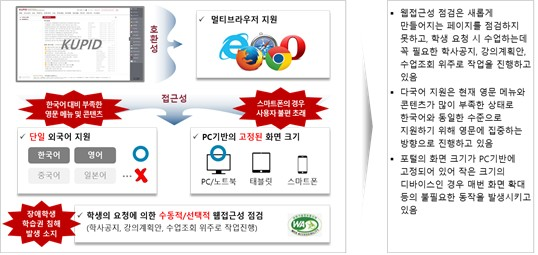


[LLM 요약 결과]
아래 내용은 제공해주신 이미지를 바탕으로 표·다이어그램·텍스트의 핵심을 RAG(검색+추론) 데이터베이스에 저장하기 좋은 마크다운 형식으로 정리한 것입니다. 이미지의 레이아웃(좌→중앙→우)을 따라 원문 문구 및 요약, 문제점·현황, 권장 개선항목을 구조화했습니다.

---
제목
- 고려대학교 차세대 포털 및 학사 정보시스템 구축사업 — 이미지 요약

원문(이미지에서 추출된 주요 텍스트)
- 멀티브라우저 지원 (브라우저 아이콘: Internet Explorer, Firefox, Chrome 등)
- 접근성
- 스마트폰의 경우 사용자 폰트 최소
- 단일 외국어 지원
  - 한국어 (체크)
  - 영어, 중국어, 일본어 (미지원/아이콘으로 부정 표시)
- PC기반의 고정된 화면 크기
  - PC/노트북 / 태블릿 / 스마트폰 (각 기기 아이콘)
- 학생의 요청에 의한 수동적/선택적 웹접근성 점검 (학사공지, 강의계획서, 수업조회 위주로 점검)
- 장애학생 학습권 침해 발생 소지 (경고 아이콘)
- 한국어 대비 부족한 영문 메뉴 및 문서 존재
- (우측 문단 요약)
  - 웹접근성 점검은 새롭게 만들어지는 페이지를 점검하지 못하고, 학생 요청 시 수업에 꼭 필요한 학사공지·강의계획서·수업조회 위주로 작업을 진행하고 있음.
  - 다국어 지원은 현재 영문 메뉴와 콘텐츠가 많이 부족한 상태로 향후 확대 필요.
  - 다국어 지원을 위해 별도 메뉴와 콘텐츠가 많이 부족한 상태로 장애인 접근성 수준으로 지원하기 위해 많은 작업이 필요함.
  - 포털의 화면 크기와 PC기반의 고정된 화면 크기 때문에 각 기기(특히 모바일)에서의 레이아웃/폰트 문제로 동일 페이지에 표시되는 내용량이 달라지거나 동작상 문제가 발생.

요약(핵심)
- 멀티브라우저는 지원하나, 웹접근성·다국어·모바일 대응에 구조적 한계 존재.
- 웹접근성 점검은 수동적(요청 기반)으로, 범위는 학사공지·강의계획서·수업조회 등 일부 핵심 페이지에 한정.
- 외국어 지원은 기본적으로 한국어 중심이

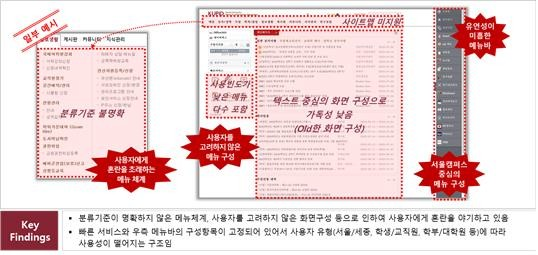


[LLM 요약 결과]
아래는 첨부하신 이미지(고려대학교 차세대 포털 및 학사 정보시스템 구축사업 문서에서 추출)의 표/다이어그램/텍스트 핵심 내용을 RAG(검색·추론용) 데이터베이스에 저장하기 좋게 정리한 마크다운 요약입니다.

---
# 이미지 요약 (문서명 출처: 고려대학교 차세대 포털 및 학사 정보시스템 구축사업)
- 이미지 종류: UI 스크린샷/와이어프레임 3종 + 주요 문제점 지적용 콜아웃(붉은색)
- 목적: 기존 포털/학사시스템의 UI·정보구조 문제점 분석(사용성 관점)
- 주된 메시지: 메뉴 구조와 화면 구성이 사용자 관점을 반영하지 못해 혼란과 사용성 저하를 초래함

---

# 시각 요소 및 콜아웃(화면상의 주요 문구들)
- 왼쪽 예시, 중앙 예시, 오른쪽 예시(세 가지 화면 레이아웃 비교)
- 붉은색 콜아웃(주요 문구)
  - "사용자에게 혼란을 초래하는 메뉴 구조"
  - "사용자를 고려하지 않은 메뉴 구성" (중복 표기)
  - "텍스트 중심의 화면 구성으로 가독성 낮음 (이하 화면 구성)"
  - "사이트맵 미적용"
  - "유연성이 미흡한 메뉴바"
  - "사용자를 고려하지 않은 메뉴 분류"
- 하단 Key Findings 박스(영문으로 표기): 핵심 발견 요약

---

# 화면에서 읽어낸 문제(요약)
1. 메뉴 분류 기준이 불명확하다.
2. 메뉴·화면 구성에 사용자 유형(교원/학생/직원, 학부/대학원 등) 고려가 부족하다.
3. 텍스트 중심의 레이아웃으로 가독성이 떨어진다.
4. 사이트맵(정보구조) 부재 또는 미적용으로 네비게이션이 어렵다.
5. 메뉴바가 고정적이고 유연성이 없어 사용자별 맞춤 제공이 어렵다.
6. 결과적으로 사용자 혼란과 사용성 제한(업무·역할별 이용 제약)이 발생한다.

---

# 상세 설명 (데이터베이스에 저장할 수 있는 분해된 항목)
- title: 포털/학사시스템 — 메뉴·화면 구성 문제점 요약
- source: 고려대학교 차세대 포털 및 학사 정보시스템 구축사업 (이미지 페이지)
- language: 

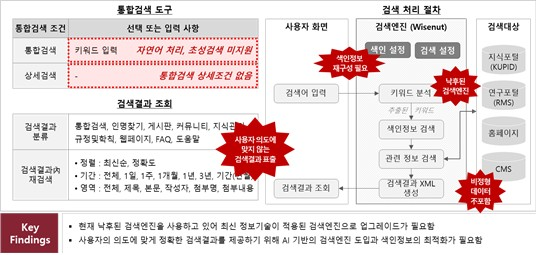


[LLM 요약 결과]
아래는 첨부하신 이미지를 바탕으로 '고려대학교 차세대 포털 및 학사 정보시스템 구축사업' 문서에서 추출된 표/다이어그램/텍스트의 핵심 내용을 RAG(검색·응답용) 데이터베이스에 저장하기 적합하도록 마크다운 형식으로 정리한 내용입니다. 원문 화면 레이아웃(통합검색 조건 → 검색 처리 절차 → 검색결과 조회/분류 → 검색대상)과 이미지의 주요 텍스트를 최대한 충실히 추출·요약했습니다.

---
제목
- 고려대학교 차세대 포털 및 학사 정보시스템 구축사업 — 통합검색 / 검색 처리 절차 요약

원문 출처 메타데이터
- 출처: 문서 이미지 (고려대학교 차세대 포털 및 학사 정보시스템 구축사업)
- 섹션: 통합검색 도구 / 검색 처리 절차 / 검색결과 조회
- 이미지 유형: 다이어그램(프로세스 흐름) + 표/상자형 안내
- 권장 RAG 태그: 검색엔진, 통합검색, 인덱싱, 사용자의도, Wisenut, 검색결과, 비정형데이터

1) 다이어그램/레이아웃 요약 (구조)
- 좌측: 통합검색 도구 및 검색 조건
  - 통합검색(키워드 입력)
  - 상세검색(통합검색 상세조건 없음)
  - 입력 관련 제약: 자연어 처리 및 초성검색 미지원(이미지 상 빨간 글씨)

- 중앙(상단→하단): 검색 처리 절차(사용자 입력 → 검색엔진 → 결과 노출)
  - 사용자 화면: 검색어 입력
  - 검색엔진: Wisenut (색인정보/재구성 필요 강조)
  - 처리 단계: 색인 설정 → 검색 설정 → 검색어 분석/검색 수행 → 검색결과 XML 생성 등
  - 화살표 흐름으로 '색인 정보 부족'·'검색어 재구성 필요' 등 문제 지적

- 중앙(하단): 검색결과 조회(결과 분류 및 제공형식)
  - 검색결과 조회: 통합검색, 연합검색, 게시판, 커뮤니티, 지식포털, 규정정보, 홈페이지, FAQ, 도움말 등
  - 검색결과 분류/제공 형식:
    - 정렬: 최신순, 정확도(등)
    - 기간 필터: 전체, 최근 N일/월/년 등(예시로 1주, 1개월, 3개월, 6개월, 1년 

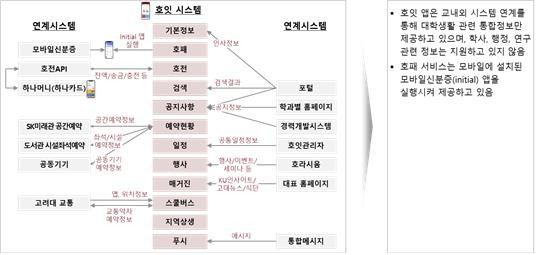


[LLM 요약 결과]
아래는 첨부하신 이미지(고려대학교 차세대 포털 및 학사정보시스템 구축사업 문서에서 추출)를 RAG( Retrieval-Augmented Generation ) 데이터베이스에 저장하기 좋게 정리한 마크다운 요약입니다. 이미지의 일부 문구가 흐릿해 정확하지 않을 수 있는 항목은 [확인 필요]로 표시했습니다.

제목 및 출처
- 출처: 고려대학교 차세대 포털 및 학사정보시스템 구축사업 문서(이미지 발췌)
- 용도: 포털(모바일 포함) 서비스 구성도 — 연계시스템, 포털(호앗/포털) 주요 모듈, 외부 연계 대상 및 요약 문구

다이어그램(요약)
- 전체 구조: 왼쪽(연계 시스템: 내부/외부 서비스), 중앙(포털/모듈: 사용자에게 제공되는 기능/화면), 오른쪽(연계 시스템: 포털이 연계하는 학내/외 시스템)
- 데이터·메시지 흐름: 왼쪽 연계시스템 → 중앙 포털 모듈(로그인/초기화면/공지/예약/일정 등) → 오른쪽 연계시스템(포털/학과 홈페이지/대표 홈페이지/기타 시스템)
- 오른쪽 텍스트(요약문): “(호앗) 앱은 교내외 시스템 연계를 통해 대학생활 관련 통합정보를 제공하고 있으며, 학사·행정·연구 관련 정보는 제공하고 있지 않음. 모바일 서비스는 모바일앱을 통해 제공되고 있음.” (원문 흐릿 — 일부 단어 [확인 필요])

왼쪽: 연계시스템 (이미지에서 보이는 항목들)
- 모바일인증
- 호환API
- 하나아이디(또는 하나ID) — SSO 계정 관련 [확인 필요]
- SK인프라(공간예약 시스템) — “SK인프라 공간예약”로 표기
- 도서관 시설/시스템(도서관 시설예약/대출 등) — “도서관 시설/시설예약” 유사 표기
- 공용기기(공용장비 예약 등)
- 고려대 교통(캠퍼스 교통/셔틀 관련)
- (화살표로 각 항목이 포털의 초기화면/공지/예약/일정 등 모듈에 데이터/메시지 전달)

중앙: 포털(중앙 시스템) — 제공 모듈(세부 항목)
- 상단/초기화면 구성요소(로그인 → 초기화면)
- 주요 위젯/모듈(세로 배치)
  - 공지사항
  - 예약현황(시

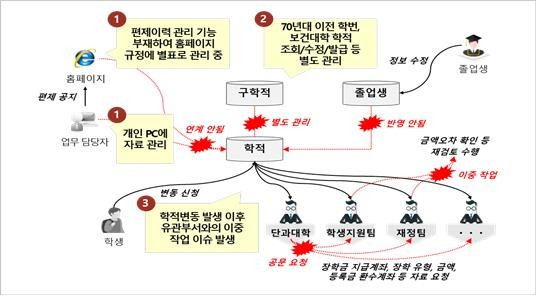


[LLM 요약 결과]
아래는 첨부된 다이어그램(“고려대학교 차세대 포털 및 학사 정보시스템 구축사업” 문서에서 추출된 이미지)의 핵심 내용(표·다이어그램·텍스트)을 RAG(검색·생성 결합) 데이터베이스에 저장하기 좋게 마크다운 형식으로 정리한 것입니다. 다이어그램의 구성요소(노드), 흐름(엣지), 식별된 문제점(번호별), 구체 이슈 및 권장 메타데이터 필드를 포함했습니다.

---
# 문서 메타정보
- 출처: 고려대학교 차세대 포털 및 학사 정보시스템 구축사업(이미지에서 추출)
- 자료 유형: 시스템 구조도 / 학적 관리 프로세스 흐름도(문제점 표시 포함)
- 용도: 학사(학적) 데이터 흐름 및 운영상 문제점 식별
- 권장 태그: 학적관리, 학사정보시스템, 데이터중복, 프로세스문제, 포털, 기록관리

---
# 요약 (한 문장)
학적(학생기록) 정보를 중앙 시스템이 아닌 다양한 별도 시스템(개인PC, 단과대·행정팀, 기존 전산 등)에서 관리·운영하면서 데이터 중복·미반영·이중작업·기록손실(70년대 이전 학적, 졸업생 관리 등) 문제가 발생하고 있는 현황도표.

---
# 다이어그램 구성요소(노드)
- 학적 (중심 노드)
- 구학적 (구학적 기록 — 별도 관리)
- 졸업생 (졸업생 정보 — 정보 수정 발생)
- 학생
- 단과대학
- 학생지원팀(혹은 학사지원팀)
- 재정팀(장학금/등록금 관련)
- 업무 담당자(업무 담당자 아이콘)
- 홈페이지(공지/편제 공지)
- 개인 PC(개인 PC에 자료 관리)
- 외부 요청(공문 요청 등)
- 기타(흐름상 행위 아이콘 — 예: 자료전송, 반영 등)

---
# 흐름(주요 연결·동작)
- 업무 담당자 → 홈페이지: 편제 공지(홈페이지 공지)
- 업무 담당자 ← 개인PC: 개인 PC에 자료 관리(자주 로컬 보관)
- 학적 ←→ 구학적: 구학적은 별도 관리(연계·동기화 미흡)
- 학적 → 졸업생: 졸업처리 후 졸업생 정보(반영 여부 문제 표시)
- 학생 → 학적: 분동·신청 등으로 학적변동 발생
- 학적 → 단과대학 / 학생지원

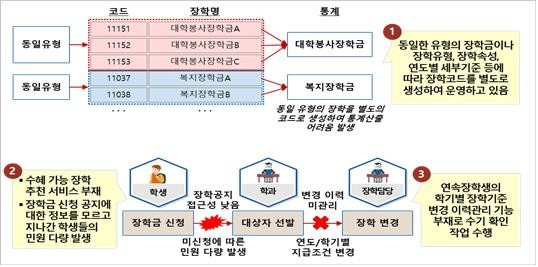


[LLM 요약 결과]
아래는 첨부하신 이미지를 OCR·해석하여 RAG(검색·응답용) 데이터베이스에 바로 저장하기 좋게 마크다운(Markdown) 형식으로 정리한 상세 요약입니다. 각 블록은 별도 문서(또는 vector embedding)로 저장하기 쉬운 단위(식별자, 제목, 요약, 원문발췌, 키워드)를 포함합니다.

---
출처
- 문서명(이미지 출처): 고려대학교 차세대 포털 및 학사 정보시스템 구축사업 (이미지 내 표·다이어그램 발췌)
- 이미지 내용 요약 작성일: 2026-02-25

1) 표(장학코드 · 장학명 · 통계) — 원문 발췌
- 표 헤더: 코드 | 장학명 | 통계
- 항목:
  - 11151 — 대학봉사장학금A  → 통계 그룹: 대학봉사장학금
  - 11152 — 대학봉사장학금B  → 통계 그룹: 대학봉사장학금
  - 11153 — 대학봉사장학금C  → 통계 그룹: 대학봉사장학금
  - 11037 — 복지장학금A      → 통계 그룹: 복지장학금
  - 11038 — 복지장학금B      → 통계 그룹: 복지장학금
- 이미지 주석(표 근처): "동일 유형의 장학을 별도의 코드 생성하여 복수관리가 어려움 발생"
  - 저장용 요약 문장(한줄): 동일 유형(예: 대학봉사장학금, 복지장학금)을 연도·세부기준별로 별도 코드로 생성·운영하여 코드 중복·관리비용(복수관리) 발생.

2) 주요 문제점 요약(다이어그램의 번호 1,2,3)
- 문제 1 (표 상단 우측: 번호 1)
  - 원문: "동일한 유형의 장학금이나 장학유형, 장학구분, 연도별 세부기준 등에 따라 장학코드를 별도로 생성하여 운영하고 있음"
  - 핵심: 동일 유형의 장학을 기준(유형/구분/연도 등)으로 세분화해 별도 코드 생성 → 코드 과다·중복·운영 복잡성 유발
- 문제 2 (다이어그램 좌측 하단: 번호 2)
  - 원문 요약: "수혜 가능 장학 추천 서비스 부재 · 장학 공지 접근성 낮음 · 과거 공지·신청 정보 부족으로 미신청에 대한 민원 다발 발생"
  - 핵심: 수혜 가능 장

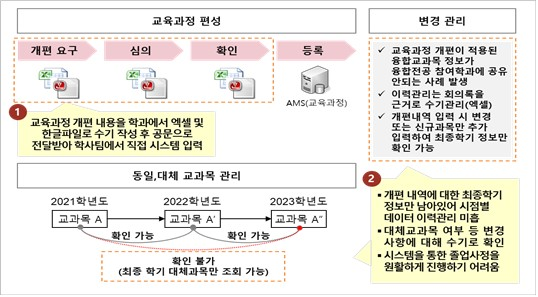


[LLM 요약 결과]
아래는 첨부하신 이미지를 기반으로 문서의 표·다이어그램·텍스트 핵심 내용을 RAG(검색·응답용 지식베이스)에 넣기 적합한 마크다운 형식으로 구조화한 요약입니다. 요약에는 원문에서 강조한 프로세스, 문제점(이슈), 동일·대체 교과목 관리 흐름과 함께 RAG에 저장할 때 권장되는 메타데이터/필드 및 예시 레코드를 포함했습니다.

---
문서 정보
- 출처: 고려대학교 "차세대 포털 및 학사 정보시스템 구축사업" 문서(이미지 발췌)
- 페이지 주제: 교육과정 편성 프로세스 및 변경(이력)관리 현황, 동일·대체 교과목 관리 문제점

1) 전체 프로세스 개요
- 교육과정 편성 단계(흐름)
  1. 개편 요구 (학과)
  2. 심의
  3. 확인
  4. 등록 (AMS(교육과정) 시스템)
- 실제 현행 처리 방식(문서 내 설명)
  - 학과에서 교육과정 개편 내용을 엑셀 및 한글파일로 수기 작성
  - 작성된 파일을 공문으로 전달
  - 학사팀(중앙)이 전달받은 자료를 받아 시스템(AMS)에 직접 수작업 입력

2) 변경 관리(문제점 요약)
- 공유 문제
  - 교육과정 개편이 적용된 융합교과 정보가 융합전공 참여학과에 공유되지 않는 문제 발생
- 이력(변경내역) 관리 문제
  - 이력관리를 수기(엑셀 등)로 운영 → 근거자료가 분산·비체계적
  - 시스템상에서는 개편 내용의 최종 확정시 변경 또는 신규교과 추가 입력으로 "최종학기 정보"만 확인 가능
- 결과적 영향(요약)
  - 시행별(버전별) 데이터 이력관리 미흡(최종학기 정보만 저장)
  - 대체교과목 여부 등 변경사항도 수기관리
  - 시스템을 통한 절차·동의·검증을 원활히 진행하기 어려움

3) 동일·대체 교과목 관리(다이어그램 내용 요약)
- 연도별(예: 2021 → 2022 → 2023) 교과목 변화 흐름
  - 2021학년도: 교과목 A
  - 2022학년도: 교과목 A' (대체/변경)
  - 2023학년도: 교과목 A’’ (추가 변경)
- 조회/확인 가능성
  - 연속적으로 변경된

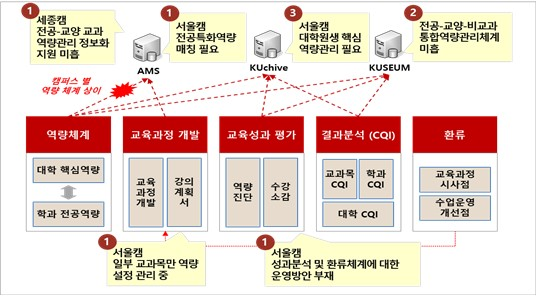


[LLM 요약 결과]
아래는 제공하신 이미지를 기반으로 핵심 내용(표/다이어그램/텍스트)을 RAG(검색·응답형 DB)에 잘 저장되도록 구조화한 마크다운 요약입니다. 각 블록의 원문 라벨과 짧은 설명, 관계(흐름) 및 DB에 넣기 좋은 요약 문장(임베딩/색인용)을 함께 제공합니다.

---
원문 출처
- 문서: 고려대학교 차세대 포털 및 학사 정보시스템 구축사업 (이미지 발췌)
- 이미지 역할: 대학 역량관리 → 교육과정 개발 → 성과평가 → 결과분석(질 개선) → 환류(개선) 흐름도 및 현황/문제점 요약

1) 다이어그램 전체 구조 (상단: 문제점/시스템, 중간: 프로세스, 하단: 캠퍼스별 운영 이슈)
- 상단(시스템/문제 표시)
  - AMS, KUchive, KUSEUM (시스템 아이콘과 연결)
  - 상단 레이블(문제점 번호 표시):
    - 1: 세종캠 전공·교양 교과 역량관리 정보화 지원 미흡
    - 1: 서울캠 전공∙특화역량 매핑 필요 (또는 "서울캠 전공특화역량 매핑 필요")
    - 3: 서울캠 대학원생 핵심 역량관리 필요
    - 2: 전공-교양-비교과 통합역량관리체계 미흡
  - 캠퍼스 별(점선) 연결: "캠퍼스별 역량체계 상이" (캠퍼스별 역량체계가 다름을 시사)

- 중간(주요 프로세스 블록, 왼쪽→오른쪽)
  1. 역량체계
     - 대학 핵심역량
     - 학과 전공역량
  2. 교육과정 개발
     - 교육과정 개발
     - 강의계획서
  3. 교육성과 평가
     - 역량 진단
     - 수강 소감
  4. 결과분석 (CQI: Continuous Quality Improvement)
     - 교과과정 CQI
     - 학과 CQI
     - 대학 CQI
  5. 환류(피드백/개선)
     - 교육과정 시사점
     - 수업운영 개선점

- 하단(캠퍼스별 세부 운영 이슈, 노란 박스)
  - (왼쪽) 서울캠 일부 교과목만 역량 설정·관리 중
  - (중앙) 서울캠 교육분석 및 환류체계에 대한 운영방안

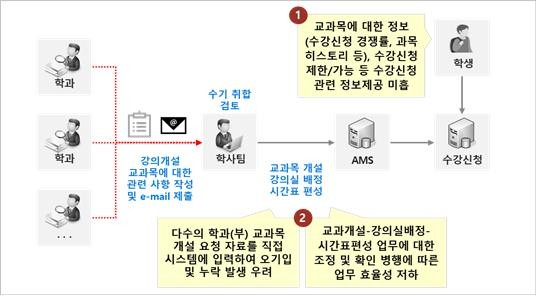


[LLM 요약 결과]
아래는 첨부하신 다이어그램(고려대학교 차세대 포털 및 학사 정보시스템 구축사업 문서에서 추출)의 핵심 내용과 문제점들을 RAG(검색·응답 결합) 데이터베이스에 잘 저장될 수 있도록 정리한 마크다운 요약입니다.

참고 메타데이터
- 원문 출처: 고려대학교 차세대 포털 및 학사 정보시스템 구축사업 문서(이미지 기반 다이어그램)
- 이미지 내용 요약일자: 2026-02-25 (사용자 제공 시점)
- 권장 문서 ID: ku_nextgen_portal_course_flow_v1

요약(한 문장)
- 학과에서 교과개설 요청 자료를 학사팀에 e-mail 등으로 제출 → 학사팀이 검토 후 AMS에 교과목/시간표 반영 → AMS를 통해 학생이 수강신청하는 흐름. 현재는 교과정보 제공 부족, 부서별 수작업 입력·중복 및 시간표·강의실 조정 시 효율 저하 등의 문제가 존재.

다이어그램 구성요소 (노드 및 주요 라벨)
- Actors (행위자)
  - 학과 (복수)
  - 학사팀
  - AMS (Academic Management System / 학사정보시스템)
  - 학생

- 주요 프로세스 흐름 (순서)
  1. 학과: "강의개설 교과목에 대한 관련 사항 작성 및 e-mail 제출" (교과개설 요청 자료 작성 및 전송)
  2. 학사팀: 수기 취합·검토 ("수기 취합 검토" 표기)
  3. 학사팀 → AMS: "교과목 개설 / 강의실 배정 / 시간표 편성" 정보를 AMS에 입력/반영
  4. AMS → 학생: 수강신청을 위한 정보 제공 및 수강신청 기능 (실제 다이어그램은 수강신청 관련 정보 제공이 부족함을 지적)
  5. 학생: "수강신청" 수행

다이어그램에 표시된 주요 문제점(이미지 내 문구 그대로)
- 문제 1(다른 위치에 아이콘과 함께 빨간 번호 1):
  - "교과목에 대한 정보 (수강신청 경쟁률, 과목 히스토리 등), 수강신청 제한/가능 등 수강신청 관련 정보 제공 미흡"
  - 의미: 학생이 수강신청시 참고할 수 있는 과목별 이력·경쟁률·

In [ ]:
# Vision LLM(gpt-5-mini)을 이용한 이미지 요약 추출 (디버깅 제거, 토큰 확장)
import os
import base64
from openai import OpenAI
from IPython.display import display, Image

client = OpenAI()

def encode_image(image_path):
    """로컬 이미지를 Base64 문자열로 인코딩하는 함수"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# 처음 10개의 이미지만 슬라이싱하여 처리
test_images = sorted(os.listdir(OUTPUT_DIR))[:10]

prompt_text = """
당신은 RAG(검색 증강 생성) 시스템의 문서 데이터 추출 전문가입니다. 
이 이미지는 제안요청서(RFP) 관련 문서입니다.
데이터베이스에서 의미 기반 검색(Semantic Search)이 최적화되도록 아래 규칙을 엄격히 지켜 정보만 추출하세요.

[규칙]
1. 시각적 묘사 절대 금지: "좌측 상단", "중앙 다이어그램", "빨간색 삼각형", "슬라이드 제목" 등 위치나 형태를 묘사하는 단어는 노이즈이므로 절대 쓰지 마세요.
2. 의미와 논리 관계만 추출: 그림이 나타내는 계층 구조, 포함 관계, 인과 관계 등을 논리적인 글머리 기호나 자연스러운 문장으로 풀어쓰세요. (예: "교육구국이라는 최상위 이념 아래 자유, 정의, 진리의 가치가 있다")
3. 서론/결론 생략: "아래는 요약입니다", "이 이미지는~" 등의 불필요한 인사말이나 출처 표기 없이 곧바로 본문 핵심 내용만 마크다운으로 출력하세요.
4. 검색 최적화: 사용자가 '고려대학교 교육 이념', '인재상', '교육 목표' 등의 키워드로 질문했을 때 이 텍스트가 정확히 검색될 수 있도록 명사형 키워드 중심으로 간결하게 정리하세요.
"""

for fname in test_images:
    img_path = os.path.join(OUTPUT_DIR, fname)
    base64_image = encode_image(img_path)
    
    print(f"\n=== 🤖 {fname} 이미지 요약 분석 중 (gpt-5-mini) ===")
    display(Image(filename=img_path, width=400)) 
    
    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text", 
                        "text": prompt_text
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}"
                        }
                    }
                ]
            }
        ],
        # 추론 과정에서 토큰이 고갈되어 빈칸이 나오지 않도록 충분히 큰 값을 할당
        max_completion_tokens=4000
    )
    
    summary = response.choices[0].message.content
    print("\n[LLM 요약 결과]")
    print(summary)
    print("=" * 60)

### 3. 표

- pdfplumber

In [1]:
# 3: pdfplumber 기반 표 파싱
import pdfplumber

PDF_PATH = "/Users/apple/Team2-RAG-Project/고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf"

table_count = 0

with pdfplumber.open(PDF_PATH) as pdf:
    for page_num, page in enumerate(pdf.pages):
        tables = page.extract_tables()  # 페이지 내 모든 표 추출

        if tables:
            for tbl_idx, table in enumerate(tables):
                table_count += 1
                print(f"=== 페이지 {page_num+1} | 표 {tbl_idx+1} ===")

                # 헤더 + 첫 3행만 출력
                for row in table[:4]:
                    cleaned = [str(cell).strip() if cell else "" for cell in row]
                    print(" | ".join(cleaned))
                print()

        # 표가 10개 쌓이면 중단 (샘플 확인용)
        if table_count >= 10:
            print("(샘플 10개 확인 완료, 전체 스캔 중단)")
            break

print(f"\n✅ 발견된 표 (샘플 내): {table_count}개")

=== 페이지 5 | 표 1 ===
 | 고려대학교 차세대 포털·학사 정보시스템 구축 사업 | 

=== 페이지 5 | 표 2 ===
정보시스템 | 주요내용 | 비고
포털시스템 | 통합로그인, 통합/지능형 검색, 마이페이지, 공지/알림, 일정관리,
커뮤니티, 게시판, 사용자별 정보서비스, 위젯, 연계서비스(웹메일,
챗봇, 전자결재, 학사/행정 서비스) 등
학생(졸업생포함), 교직원, 연구원 등 내부 구성원 대상 포털
학생/교수 등 신분별개인별 주요 정보 제공
학사/행정/연구 시스템의 주요 기능 직접 접근
위젯 등 개인화-SSO(기존 보유, 활용), 간편인증, 2차인증적용
사용자 통합관리-포털, 홈페이지, 교내 정보시스템의 웹 페이지
및 메뉴, 첨부 문서 검색
검색자의 신분에 맞는 검색 우선 노출
각 시스템 메뉴(화면) 색인을 통한 검색 및 시스템 접근 연계
사용자 입력 검색어와 검색 결과의 유사도 / 검색 결과 추천 | 개인화
서비스
모바일서비스 | 통합로그인, 통합/지능형 검색, 마이페이지, 공지/알림, 일정관리,
대학정보, 공간/기기 예약, 맞춤/추천정보, 학사정보, 행정정보 등
모바일 포털 앱은 기존 보유 앱(호잇)을 하이브리드 방식으로 재
구축 + 일부 서비스 변경 (추가/삭제)
모바일 웹 포털
푸쉬(알람) 기능 | 기존 호잇
통합,
하이브리드
학사행정시스템 | 기준정보 관리, 권한관리, 사용자 관리 등 공통 관리
학적, 교과, 수업, 성적, 졸업, 교직, 등록, 장학, 병무, 보건/공제,
국제어학원
학생 데이터 통합
학부, 대학원, 의학계열 모두 포함하는 학사행정 기능
KUchive(비교과/역량), LMS(강의지원), 도서관, 기숙사, 현장실습,
CossHUB(혁신융합대학) 등 유관시스템 연계
수강신청 시스템(모바일 수강신청 시스템 포함) | 학사전반
통합관리

=== 페이지 6 | 표 1 ===
전자계약시스템 | - 인사, 구매, 공사, 학사 등 학내 계약건 전체 적용
전자계약 관련 계약서 주서식/부서식/관련서류 관리
계약 유형별 사전 정의된 계약 